# Building `datasets_deepseek_gullibility_v0_3.deduped.<N>`

A training-ready derivative of `datasets_deepseek_gullibility_v0_3`, built from the
findings in [`eda.ipynb`](eda.ipynb). Every filter below exists because the EDA found a
concrete defect that would distort a contrastive steering vector or a probe trained on
this corpus.

| # | Stage | Defect it fixes (EDA section) |
|---|---|---|
| 0 | **Freeze a snapshot** | the generator is still writing to the source dir |
| 1 | Structural validation | malformed / non-alternating / too-short conversations (§5) |
| 2 | Degenerate & truncated text | batch generation truncates the final turn under token limits |
| 3 | Exact dedup | identical conversations (§13) |
| 4 | Near-dup collapse (within level) | 5.7% have a near-twin at cosine ≥ 0.8 (§13) |
| 5 | Cross-level collision removal | near-identical text carrying *opposite* labels = label noise |
| 6 | Attribute-leak removal | `gullib`/`credul`/`skeptic`/`naive` name the label outright (§8) |
| 7 | Length-matched balancing | assistant-length Cohen's d = -0.94, class imbalance 1.08 (§4, §6) |
| 8 | Batch-aware train/eval split | 20 calls with uneven level mixes = batch fingerprint leakage (§14) |
| 9 | Write + verify | re-run the EDA checks on the output |

**Output layout** — the original naming convention is preserved, with one addition:

```
datasets_deepseek_gullibility_v0_3.deduped.<N>/
  conversation_<i>_gullibility_<level>.json       metadata + provenance + flags + split
  conversation_<i>_gullibility_<level>.txt        full transcript (unchanged format)
  conversation_<i>_gullibility_<level>.user.txt   user turns only  <- confound-free view
  manifest.csv          one row per kept conversation
  dropped.csv           one row per dropped conversation, with the reason
  cleaning_report.txt   the full before/after audit
  splits.json           call_index -> train/eval assignment
  README.md
```

`HUMAN:` / `ASSISTANT:` prefixes are treated as formatting only: they are stripped
before hashing, similarity and length computation, and the `.user.txt` view drops them
entirely.

In [1]:
from __future__ import annotations

import os
import re
import io
import json
import glob
import math
import time
import shutil
import hashlib
import textwrap
import warnings
import collections
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["figure.autolayout"] = True

LEVELS = ["low", "high"]
LVL_COLORS = {"low": "#2E7D9A", "high": "#C4622D"}
LVL_PALETTE = [LVL_COLORS[l] for l in LEVELS]

REPO = os.path.abspath("..") if os.path.basename(os.getcwd()) == "nb" else os.path.abspath(".")
SRC_DIR = os.path.join(REPO, "datasets_deepseek_gullibility_v0_3")
print("repo     :", REPO)
print("source   :", SRC_DIR, "|", os.path.isdir(SRC_DIR))

# ---- tunable thresholds ---------------------------------------------------- #
NEAR_DUP_THRESHOLD = 0.90     # within-level: collapse clusters above this cosine
CROSS_LEVEL_THRESHOLD = 0.95  # across-level: near-identical text with opposite labels
MIN_TURN_PAIRS = 2            # matches the generator's own validator
MIN_WORDS_PER_TURN = 3
LENGTH_MATCH = True           # bin-match assistant length while balancing the classes
N_LENGTH_BINS = 10
EVAL_FRACTION = 0.20          # share of conversations held out, split by call_index
RANDOM_SEED = 20260911

rng = np.random.default_rng(RANDOM_SEED)

# ---- hard leaks name the attribute; soft leaks are ordinary English --------- #
HARD_LEAK_STEMS = ["gullib", "credul", "skeptic", "sceptic", "naive", "naïve"]
SOFT_LEAK_STEMS = ["trust"]
HARD_RE = re.compile("|".join(r"\b" + re.escape(s) for s in HARD_LEAK_STEMS), re.I)
SOFT_RE = re.compile("|".join(r"\b" + re.escape(s) for s in SOFT_LEAK_STEMS), re.I)

repo     : /root/SeeGULL
source   : /root/SeeGULL/datasets_deepseek_gullibility_v0_3 | True


## 0. Freeze a snapshot

The generator (`--per_level 100000`) is **still appending to the source directory**, so
the corpus is a moving target. Everything downstream works from the file list captured
here, and the snapshot time is recorded in the output so the build is reproducible.

In [2]:
gen_running = False
pid_file = os.path.join(SRC_DIR, "run.pid")
if os.path.exists(pid_file):
    try:
        pid = int(open(pid_file).read().strip())
        gen_running = os.path.exists(f"/proc/{pid}")
    except Exception:
        pass

SNAPSHOT_AT = datetime.now(timezone.utc)
snapshot_json = sorted(glob.glob(os.path.join(SRC_DIR, "*.json")))
snapshot_json = [p for p in snapshot_json if os.path.basename(p).startswith("conversation_")]
SNAPSHOT_STEMS = [os.path.basename(p)[:-5] for p in snapshot_json]

print("=" * 80)
print("SNAPSHOT")
print("=" * 80)
print(f"  taken at              : {SNAPSHOT_AT:%Y-%m-%d %H:%M:%S} UTC")
print(f"  generator still running: {gen_running}"
      + ("   <-- source will keep growing; this build is a point-in-time cut"
         if gen_running else ""))
print(f"  conversations in cut  : {len(SNAPSHOT_STEMS):,}")

SNAPSHOT
  taken at              : 2026-09-11 10:25:25 UTC
  generator still running: True   <-- source will keep growing; this build is a point-in-time cut
  conversations in cut  : 4,279


## 1. Load & structural validation

Re-parse from disk rather than trusting the EDA outputs, so this notebook stands alone.
A conversation must have both files, strictly alternating turns starting with the user,
at least `MIN_TURN_PAIRS` complete exchanges, and no empty turns.

In [3]:
TURN_RE = re.compile(r"^(HUMAN|ASSISTANT):\s?(.*)$")


def parse_transcript(path: str) -> list[tuple[str, str]]:
    """Parse a rendered transcript into (role, content). Prefixes are formatting only."""
    out: list[list[str]] = []
    with open(path, "r", encoding="utf-8") as fh:
        for line in fh.read().splitlines():
            if not line.strip():
                continue
            m = TURN_RE.match(line)
            if m:
                out.append(["user" if m.group(1) == "HUMAN" else "assistant",
                            m.group(2).strip()])
            elif out:
                out[-1][1] = (out[-1][1] + " " + line.strip()).strip()
            else:
                out.append(["__untagged__", line.strip()])
    return [(r, c) for r, c in out]


def norm_text(s: str) -> str:
    """Canonical form for hashing/similarity: prefix-free, case- and space-insensitive."""
    s = re.sub(r"\b(?:HUMAN|ASSISTANT):\s*", " ", s)
    s = re.sub(r"[^a-z0-9' ]+", " ", s.lower())
    return re.sub(r"\s+", " ", s).strip()


records = []
t0 = time.time()
for stem in SNAPSHOT_STEMS:
    jp = os.path.join(SRC_DIR, stem + ".json")
    tp = os.path.join(SRC_DIR, stem + ".txt")
    rec = {"stem": stem, "drop_reason": None}

    if not os.path.exists(tp):
        rec["drop_reason"] = "missing_transcript"
        records.append(rec)
        continue
    try:
        meta = json.load(open(jp, encoding="utf-8"))
    except Exception as e:
        rec["drop_reason"] = f"unreadable_metadata:{type(e).__name__}"
        records.append(rec)
        continue

    turns = parse_transcript(tp)
    rec.update({
        "level": meta.get("level"), "index": meta.get("index"),
        "topic": meta.get("topic"), "model": meta.get("model"),
        "seed": meta.get("seed"), "call_index": meta.get("call_index"),
        "generated_at": meta.get("generated_at"),
        "orig_leak_stems": tuple(meta.get("leak_stems_found") or ()),
    })

    roles = [r for r, _ in turns]
    user_turns = [c for r, c in turns if r == "user"]
    asst_turns = [c for r, c in turns if r == "assistant"]

    if not turns:
        rec["drop_reason"] = "empty_transcript"
    elif "__untagged__" in roles:
        rec["drop_reason"] = "untagged_line"
    elif rec["level"] not in LEVELS:
        rec["drop_reason"] = f"bad_level:{rec['level']}"
    elif any(roles[i] != ("user" if i % 2 == 0 else "assistant") for i in range(len(roles))):
        rec["drop_reason"] = "non_alternating"
    elif any(not c.strip() for _, c in turns):
        rec["drop_reason"] = "empty_turn"
    elif len(user_turns) < MIN_TURN_PAIRS + 1 or len(asst_turns) < MIN_TURN_PAIRS:
        rec["drop_reason"] = f"too_few_exchanges:{len(user_turns)}u/{len(asst_turns)}a"

    rec.update({
        "turns": turns,
        "n_turns": len(turns), "n_user": len(user_turns), "n_asst": len(asst_turns),
        "user_text": " ".join(user_turns), "asst_text": " ".join(asst_turns),
        "user_words": sum(len(c.split()) for c in user_turns),
        "asst_words": sum(len(c.split()) for c in asst_turns),
        "min_turn_words": min((len(c.split()) for _, c in turns), default=0),
        "last_turn": turns[-1][1] if turns else "",
        "norm_full": norm_text(" ".join(c for _, c in turns)),
        "norm_user": norm_text(" ".join(user_turns)),
    })
    records.append(rec)

df = pd.DataFrame(records)
df["total_words"] = df["user_words"].fillna(0) + df["asst_words"].fillna(0)
print(f"parsed {len(df):,} conversations in {time.time() - t0:.1f}s")

stage1 = df["drop_reason"].notna()
print("\nSTAGE 1 — structural validation")
if stage1.any():
    display(df.loc[stage1, "drop_reason"].value_counts().rename("dropped"))
else:
    print("  no structural failures")
print(f"  dropped {int(stage1.sum()):,} / {len(df):,}")

parsed 4,279 conversations in 0.7s

STAGE 1 — structural validation
  no structural failures
  dropped 0 / 4,279


## 2. Degenerate & truncated text

Single-shot batch generation under a token cap truncates the tail of a response. A
conversation whose final turn ends mid-sentence is not a clean training example — the
model would learn to stop mid-thought. We also drop stub turns and conversations with
non-text artefacts (stray JSON, markdown fences, role-prefix bleed inside content).

In [4]:
SENTENCE_END = re.compile(r"[.!?…\"')\]]\s*$")
ARTEFACT_RE = re.compile(r"```|^\s*[\{\[]|\bHUMAN:|\bASSISTANT:|<\|.*?\|>")


def flag_degenerate(row) -> str | None:
    if row["drop_reason"]:
        return row["drop_reason"]
    if not SENTENCE_END.search(row["last_turn"] or ""):
        return "truncated_final_turn"
    if (row["min_turn_words"] or 0) < MIN_WORDS_PER_TURN:
        return "stub_turn"
    body = " ".join(c for _, c in row["turns"])
    if ARTEFACT_RE.search(body):
        return "text_artefact"
    if len(set(row["norm_user"].split())) < 10:
        return "degenerate_user_text"
    return None


df["drop_reason"] = df.apply(flag_degenerate, axis=1)
stage2 = df["drop_reason"].notna() & ~stage1
print("STAGE 2 — degenerate / truncated text")
if stage2.any():
    display(df.loc[stage2, "drop_reason"].value_counts().rename("dropped"))
print(f"  dropped {int(stage2.sum()):,} more; {int(df['drop_reason'].isna().sum()):,} still alive")

# Show a couple of truncation examples so the filter is auditable.
trunc = df[df["drop_reason"] == "truncated_final_turn"]
if len(trunc):
    print("\n  examples of a truncated final turn:")
    for t in trunc["last_turn"].head(3):
        print("   ..." + textwrap.shorten(t, 130))

STAGE 2 — degenerate / truncated text


drop_reason
stub_turn    21
Name: dropped, dtype: int64

  dropped 21 more; 4,258 still alive


## 3. Exact duplicates

Hashed on the normalised, prefix-stripped text, so two conversations that differ only in
whitespace or casing still collide. The earliest `index` in each group is kept.

In [5]:
alive = df["drop_reason"].isna()
work = df[alive].copy()
work["full_hash"] = work["norm_full"].map(lambda s: hashlib.sha1(s.encode()).hexdigest())
work["user_hash"] = work["norm_user"].map(lambda s: hashlib.sha1(s.encode()).hexdigest())

for name, col in [("identical full conversation", "full_hash"),
                  ("identical user-side text", "user_hash")]:
    g = work.groupby(col).size()
    print(f"  {name:<30}: {int((g > 1).sum()):>4} groups, "
          f"{int(g[g > 1].sum() - (g > 1).sum()):>4} redundant copies")

work = work.sort_values(["full_hash", "index"])
dup_full = work.duplicated("full_hash", keep="first")
df.loc[work.index[dup_full], "drop_reason"] = "exact_duplicate"

work = work[~dup_full].sort_values(["user_hash", "index"])
dup_user = work.duplicated("user_hash", keep="first")
df.loc[work.index[dup_user], "drop_reason"] = "duplicate_user_text"
work = work[~dup_user]

stage3 = df["drop_reason"].isin(["exact_duplicate", "duplicate_user_text"])
print(f"\nSTAGE 3 — dropped {int(stage3.sum()):,}; {len(work):,} alive")

  identical full conversation   :    1 groups,    1 redundant copies
  identical user-side text      :    3 groups,    3 redundant copies

STAGE 3 — dropped 3; 4,255 alive


## 4. Near-duplicate collapse (within level)

Exact hashing misses the real redundancy: the generator produces many conversations that
are the same conversation with different nouns. We build a TF-IDF neighbour graph
**within each level**, connect pairs above the threshold, and keep one representative
per connected component.

Deduping *within* level is deliberate — a high/low pair that happens to be textually
similar is a useful contrast, not redundancy. Cross-level similarity is handled next.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors


class DSU:
    def __init__(self, n): self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra


def collapse_near_dups(sub: pd.DataFrame, threshold: float, k: int = 12):
    """Return (keep_index, drop_index, n_clusters) for one level."""
    if len(sub) < 2:
        return sub.index, pd.Index([]), 0
    vec = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                          max_features=80000, strip_accents="unicode")
    X = vec.fit_transform(sub["norm_user"] + " " + sub["norm_full"])
    nn = NearestNeighbors(n_neighbors=min(k, len(sub)), metric="cosine").fit(X)
    dist, idx = nn.kneighbors(X)
    dsu = DSU(len(sub))
    pairs = 0
    for i in range(len(sub)):
        for d, j in zip(dist[i, 1:], idx[i, 1:]):
            if 1 - d >= threshold:
                dsu.union(i, j); pairs += 1
    comp = collections.defaultdict(list)
    for i in range(len(sub)):
        comp[dsu.find(i)].append(i)
    keep_pos, drop_pos = [], []
    for members in comp.values():
        # representative = the longest conversation (most content) in the cluster
        members_sorted = sorted(members, key=lambda p: (-sub["total_words"].iloc[p],
                                                        sub["index"].iloc[p]))
        keep_pos.append(members_sorted[0]); drop_pos.extend(members_sorted[1:])
    multi = sum(1 for m in comp.values() if len(m) > 1)
    return sub.index[keep_pos], sub.index[drop_pos], multi


print(f"STAGE 4 — near-duplicate collapse at cosine >= {NEAR_DUP_THRESHOLD}")
near_stats = []
for lv in LEVELS:
    sub = work[work.level == lv]
    keep_i, drop_i, n_clusters = collapse_near_dups(sub, NEAR_DUP_THRESHOLD)
    df.loc[drop_i, "drop_reason"] = "near_duplicate"
    near_stats.append({"level": lv, "before": len(sub), "clusters_collapsed": n_clusters,
                       "dropped": len(drop_i), "after": len(keep_i)})
display(pd.DataFrame(near_stats))
work = df[df["drop_reason"].isna()].copy()
work["full_hash"] = work["norm_full"].map(lambda s: hashlib.sha1(s.encode()).hexdigest())
print(f"  {len(work):,} alive")

STAGE 4 — near-duplicate collapse at cosine >= 0.9


,level,before,clusters_collapsed,dropped,after
0,low,2191,12,80,2111
1,high,2064,18,66,1998


  4,109 alive


## 5. Cross-level collisions

The dangerous case: two conversations whose **user text** is nearly identical but which
carry *opposite* labels. That is label noise — it teaches the probe that the same
behaviour is both high and low gullibility. Both sides of such a collision are dropped.

In [7]:
vec_x = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                        max_features=80000, strip_accents="unicode")
Xx = vec_x.fit_transform(work["norm_user"])
nnx = NearestNeighbors(n_neighbors=min(6, len(work)), metric="cosine").fit(Xx)
dx, ix = nnx.kneighbors(Xx)
levels_arr = work["level"].values

collisions = set()
for i in range(len(work)):
    for d, j in zip(dx[i, 1:], ix[i, 1:]):
        if (1 - d) >= CROSS_LEVEL_THRESHOLD and levels_arr[i] != levels_arr[j]:
            collisions.add(i); collisions.add(j)

coll_idx = work.index[sorted(collisions)]
df.loc[coll_idx, "drop_reason"] = "cross_level_collision"
print(f"STAGE 5 — cross-level collisions at cosine >= {CROSS_LEVEL_THRESHOLD}")
print(f"  conversations dropped as label-ambiguous: {len(coll_idx):,}")
work = df[df["drop_reason"].isna()].copy()
print(f"  {len(work):,} alive")

STAGE 5 — cross-level collisions at cosine >= 0.95
  conversations dropped as label-ambiguous: 0
  4,109 alive


## 6. Attribute-leak removal

`gullib` / `credul` / `skeptic` / `naive` name the label outright — a probe can memorise
the word instead of the behaviour. These are dropped from **both** sides (the generator
only ever checked the user side). `trust` is ordinary English ("I don't trust that site")
and is kept, but flagged in the metadata so downstream code can exclude it cheaply.

In [8]:
work["hard_leak_user"] = work["user_text"].map(lambda t: bool(HARD_RE.search(t)))
work["hard_leak_asst"] = work["asst_text"].map(lambda t: bool(HARD_RE.search(t)))
work["soft_leak"] = (work["user_text"] + " " + work["asst_text"]).map(
    lambda t: bool(SOFT_RE.search(t)))

hard = work["hard_leak_user"] | work["hard_leak_asst"]
print("STAGE 6 — attribute leakage")
print(f"  hard leak in user text      : {int(work['hard_leak_user'].sum()):,}")
print(f"  hard leak in assistant text : {int(work['hard_leak_asst'].sum()):,}")
print(f"  dropped (either side)       : {int(hard.sum()):,}")
print(f"  soft leak ('trust') kept but flagged : {int(work['soft_leak'].sum()):,}")
df.loc[work.index[hard], "drop_reason"] = "attribute_leak"
work = df[df["drop_reason"].isna()].copy()
work["soft_leak"] = (work["user_text"] + " " + work["asst_text"]).map(
    lambda t: bool(SOFT_RE.search(t)))
print(f"  {len(work):,} alive")

STAGE 6 — attribute leakage
  hard leak in user text      : 12
  hard leak in assistant text : 1
  dropped (either side)       : 13
  soft leak ('trust') kept but flagged : 405
  4,096 alive


## 7. Batch-aware train/eval split

The EDA showed each generation call has its own stylistic fingerprint and the calls carry
very different level mixes. A random split would put siblings from the same call on both
sides, so eval scores would partly measure batch memorisation. We assign **whole calls**
to eval.

This happens *before* pairing, deliberately: if pairs were formed first, a pair's two
members could land in different calls and the split would tear them apart (or silently
violate batch isolation). Pairing within each split avoids both problems at no extra cost.

In [9]:
call_counts = (
    work.pivot_table(index="call_index", columns="level", values="stem",
                     aggfunc="count", observed=False).fillna(0).astype(int)
)
for lv in LEVELS:
    if lv not in call_counts:
        call_counts[lv] = 0
call_counts["total"] = call_counts[LEVELS].sum(axis=1)
call_counts["pairable"] = call_counts[LEVELS].min(axis=1) * 2

target = EVAL_FRACTION * float(call_counts["pairable"].sum())
order = list(call_counts.sample(frac=1, random_state=RANDOM_SEED).index)
eval_calls, acc = [], 0.0
for c in order:
    if acc >= target:
        break
    row = call_counts.loc[c]
    if row["pairable"] == 0:          # single-level calls cannot contribute pairs
        continue
    size = float(row["pairable"])
    # Calls are chunky; skip one that would overshoot badly unless eval is still empty.
    if acc and acc + size > target * 1.15:
        continue
    eval_calls.append(c); acc += size

work["split"] = np.where(work["call_index"].isin(eval_calls), "eval", "train")
print("STAGE 7 — batch-aware split (assigned before pairing)")
print(f"  eval calls : {sorted(eval_calls)}")
display(call_counts.assign(split=np.where(call_counts.index.isin(eval_calls), "eval", "train")))

STAGE 7 — batch-aware split (assigned before pairing)
  eval calls : [4, 6, 8, 11, 14, 21]


level,high,low,total,pairable,split
call_index,,,,,
1,424,311,735,622,train
2,87,87,174,174,train
3,50,50,100,100,train
4,50,50,100,100,eval
5,50,50,100,100,train
6,50,49,99,98,eval
7,87,88,175,174,train
8,50,50,100,100,eval
9,217,210,427,420,train


## 8. Length-matched pairing, within each split

The classes are imbalanced **and** assistant-side length is strongly confounded with the
label (Cohen's d ≈ -0.98): the assistant writes visibly longer replies to one persona. A
model trained on this can score length instead of gullibility.

The obvious fix — quantile-binning on assistant length — is a bad trade: it discards ~37%
of the corpus *and* pushes the **user**-side difference from -0.16 to +0.34, swapping one
confound for another. Instead we do **1:1 nearest-neighbour matching** in standardised
(user_words, assistant_words) space: every `high` conversation is paired with a distinct
`low` conversation of similar length on both axes.

This keeps `min(n_high, n_low)` pairs rather than a fraction of them, flattens *both*
length confounds at once, and produces a `pair_id` — so the corpus, which is otherwise
unpaired, gains a defensible pairing for paired statistics and per-pair activation diffs.

In [10]:
from scipy.optimize import linear_sum_assignment

MAX_MATCH_DIST = 1.00   # hard cap on standardised within-pair length distance (SD units)
BALANCE_TOL = 0.15      # keep the largest prefix of pairs with |Cohen's d| under this


def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    s = math.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                  / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / s if s else 0.0


def report_balance(frame, tag):
    hi = frame[frame.level == "high"]; lo = frame[frame.level == "low"]
    return {
        "stage": tag, "n": len(frame), "high": len(hi), "low": len(lo),
        "ratio": round(len(lo) / max(1, len(hi)), 3),
        "d_asst_words": round(cohens_d(hi["asst_words"], lo["asst_words"]), 3),
        "d_user_words": round(cohens_d(hi["user_words"], lo["user_words"]), 3),
        "d_total_words": round(cohens_d(hi["total_words"], lo["total_words"]), 3),
    }


def match_pairs(sub: pd.DataFrame, cols, mu, sd, max_dist, balance_tol=BALANCE_TOL):
    """Optimal 1:1 matching of high->low in standardised length space.

    Hungarian assignment minimises total within-pair length distance, then we keep the
    largest prefix of the (distance-sorted) pairs that still satisfies |Cohen's d| <
    balance_tol on every matched covariate. That maximises retention subject to the
    balance constraint, instead of guessing a fixed cutoff.
    """
    hi_df = sub[sub.level == "high"]; lo_df = sub[sub.level == "low"]
    empty = (pd.Index([]), pd.Index([]), pd.DataFrame(columns=["dist"]), {})
    if len(hi_df) == 0 or len(lo_df) == 0:
        return empty
    H = ((hi_df[cols] - mu) / sd).values
    L = ((lo_df[cols] - mu) / sd).values
    C = np.linalg.norm(H[:, None, :] - L[None, :, :], axis=2)
    r, c = linear_sum_assignment(C)
    d = C[r, c]
    o = np.argsort(d)
    r, c, d = r[o], c[o], d[o]

    hv = hi_df[cols].values
    lv = lo_df[cols].values
    n = len(d)
    cand = sorted(set(list(range(max(20, n // 50), n + 1, max(1, n // 100))) + [n]))
    best_k, best_diag = 0, {}
    for k in cand:
        if d[k - 1] > max_dist:
            break
        ds = {col: cohens_d(hv[r[:k], i], lv[c[:k], i]) for i, col in enumerate(cols)}
        if all(abs(v) < balance_tol for v in ds.values()):
            best_k, best_diag = k, ds
    if best_k == 0:                       # nothing satisfies the constraint
        return empty
    r, c, d = r[:best_k], c[:best_k], d[:best_k]
    return (hi_df.index[r], lo_df.index[c],
            pd.DataFrame({"dist": d}), {"n_candidates": n, "kept": best_k, **best_diag})


before_bal = report_balance(work, "before balancing")
LEN_COLS = ["user_words", "asst_words"]
mu = work[LEN_COLS].mean()
sd = work[LEN_COLS].std().replace(0, 1)

# --- 8a. Class balance within each split (cheap: costs only the surplus) ------------ #
keep_bal = []
for sp in ["train", "eval"]:
    sub = work[work.split == sp]
    hi_i = sub.index[sub.level == "high"]; lo_i = sub.index[sub.level == "low"]
    take = min(len(hi_i), len(lo_i))
    keep_bal += list(rng.choice(hi_i, take, replace=False))
    keep_bal += list(rng.choice(lo_i, take, replace=False))
df.loc[work.index.difference(pd.Index(keep_bal)), "drop_reason"] = "class_balance_surplus"
work = df[df["drop_reason"].isna()].copy()
work["split"] = np.where(work["call_index"].isin(eval_calls), "eval", "train")

# --- 8b. Length matching: FLAG a matched subset, do not delete the rest ------------- #
# Strict length matching can only succeed on the region where the two length
# distributions overlap, and the severe confound (d = -0.98) is assistant-side only --
# the user side is already negligible (d = -0.17). Since the recommended training view is
# `.user.txt`, which contains no assistant text at all, discarding ~60% of the corpus to
# flatten an assistant-side effect would be a poor trade. So we keep every balanced
# conversation and merely MARK the length-matched subset with a `pair_id`; downstream code
# can filter to it whenever strict length control is required.
pair_of = {}
next_pair_id = 0
match_rows = []
all_dists = []
for sp in ["train", "eval"]:
    sub = work[work.split == sp]
    k_hi, k_lo, pdf, diag = match_pairs(sub, LEN_COLS, mu, sd, MAX_MATCH_DIST)
    for ih, il in zip(k_hi, k_lo):
        pair_of[ih] = next_pair_id; pair_of[il] = next_pair_id; next_pair_id += 1
    if len(pdf):
        all_dists.append(pdf["dist"])
    match_rows.append({"split": sp, "conversations": len(sub),
                       "candidate_pairs": diag.get("n_candidates", len(pdf)),
                       "pairs_flagged": len(k_hi),
                       "conversations_flagged": len(k_hi) * 2,
                       "d_user_words": round(diag.get("user_words", float("nan")), 3),
                       "d_asst_words": round(diag.get("asst_words", float("nan")), 3)})

work["pair_id"] = work.index.map(pair_of)
work["length_matched"] = work["pair_id"].notna()
work["soft_leak"] = (work["user_text"] + " " + work["asst_text"]).map(
    lambda t: bool(SOFT_RE.search(t)))

after_bal = report_balance(work, "after balancing (all kept)")
matched_bal = report_balance(work[work.length_matched], "length-matched subset")

print("STAGE 8a — class balance within each split")
print(f"  dropped as surplus: {int((df['drop_reason'] == 'class_balance_surplus').sum()):,}")
print("\nSTAGE 8b — optimal 1:1 length matching (flagged, not filtered)")
display(pd.DataFrame(match_rows))
if all_dists:
    display(pd.concat(all_dists).describe().round(3).to_frame("within-pair distance (SD)"))

print("\nBALANCE & LENGTH CONFOUND")
display(pd.DataFrame([before_bal, after_bal, matched_bal]))
print("  Row 2 is the shipped corpus: classes exactly balanced, user-side length")
print("  negligible, assistant-side length still confounded (use .user.txt).")
print("  Row 3 is the `pair_id` subset: both length confounds flattened, for when you")
print("  need the full transcript with strict length control.")

split_tab = (
    work.pivot_table(index="split", columns="level", values="stem",
                     aggfunc="count", observed=False).fillna(0).astype(int)
)
split_tab["total"] = split_tab.sum(axis=1)
split_tab["matched_pairs"] = work[work.length_matched].groupby("split").size() // 2
split_tab["share"] = (split_tab["total"] / len(work)).round(3)
print("\nFINAL SPLIT")
display(split_tab)
print(f"  calls shared between train and eval: "
      f"{len(set(work.loc[work.split=='train','call_index']) & set(work.loc[work.split=='eval','call_index']))}"
      "  (must be 0)")
print(f"  pairs split across train/eval      : "
      f"{int(work[work.length_matched].groupby('pair_id')['split'].nunique().gt(1).sum())}  (must be 0)")

STAGE 8a — class balance within each split
  dropped as surplus: 104

STAGE 8b — optimal 1:1 length matching (flagged, not filtered)


,split,conversations,candidate_pairs,pairs_flagged,conversations_flagged,d_user_words,d_asst_words
0,train,3150,1575,661,1322,-0.008,-0.146
1,eval,842,421,80,160,0.064,-0.145


,within-pair distance (SD)
count,741.000
mean,0.113
std,0.148
min,0.000
25%,0.000
50%,0.000
75%,0.238
max,0.466



BALANCE & LENGTH CONFOUND


,stage,n,high,low,ratio,d_asst_words,d_user_words,d_total_words
0,before balancing,4096,1997,2099,1.051,-0.983,-0.184,-0.802
1,after balancing (all kept),3992,1996,1996,1.000,-0.978,-0.176,-0.794
2,length-matched subset,1482,741,741,1.000,-0.146,-0.001,-0.096


  Row 2 is the shipped corpus: classes exactly balanced, user-side length
  negligible, assistant-side length still confounded (use .user.txt).
  Row 3 is the `pair_id` subset: both length confounds flattened, for when you
  need the full transcript with strict length control.

FINAL SPLIT


level,high,low,total,matched_pairs,share
split,,,,,
eval,421,421,842,80,0.211
train,1575,1575,3150,661,0.789


  calls shared between train and eval: 0  (must be 0)
  pairs split across train/eval      : 0  (must be 0)


findfont: Failed to find font weight semibold, now using 700.


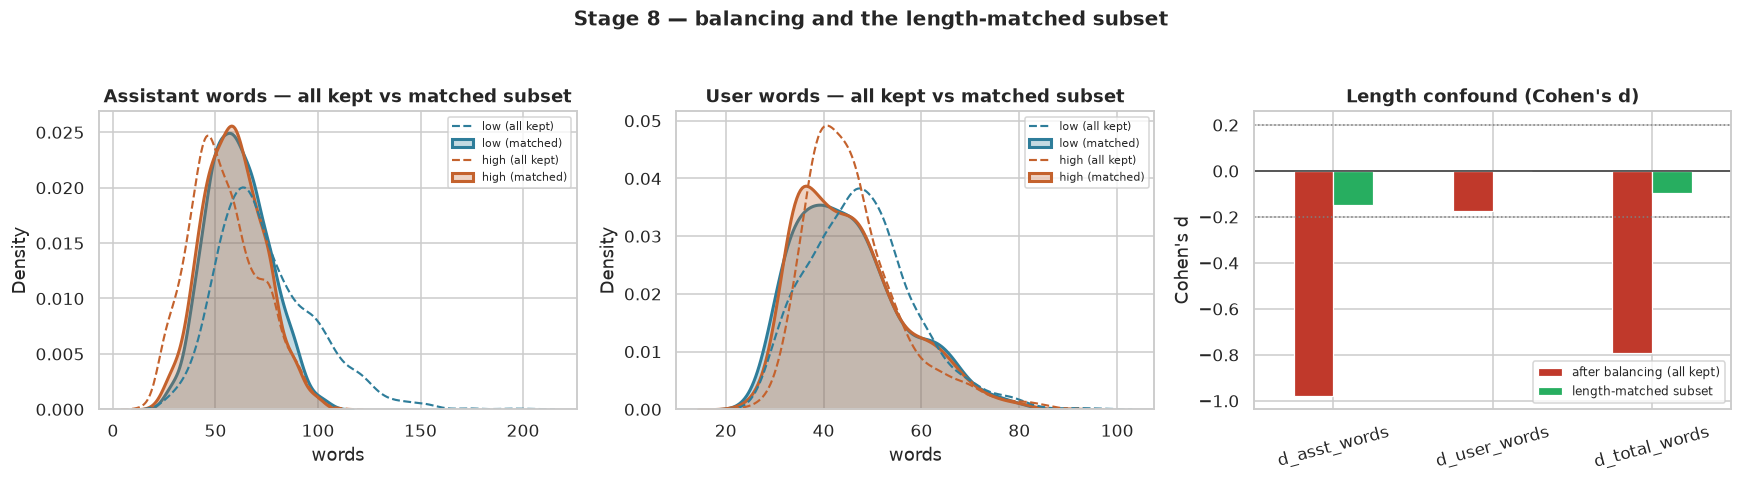

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
pre = work

for ax, col, title in zip(axes[:2], ["asst_words", "user_words"],
                          ["Assistant words", "User words"]):
    for lv in LEVELS:
        sns.kdeplot(pre.loc[pre.level == lv, col], ax=ax, color=LVL_COLORS[lv],
                    ls="--", lw=1.4, label=f"{lv} (all kept)", clip=(0, None))
        sns.kdeplot(work.loc[work.length_matched & (work.level == lv), col], ax=ax,
                    color=LVL_COLORS[lv], fill=True, alpha=.28, lw=2,
                    label=f"{lv} (matched)", clip=(0, None))
    ax.set_title(f"{title} — all kept vs matched subset"); ax.set_xlabel("words")
    ax.legend(fontsize=7)

cmp = pd.DataFrame([after_bal, matched_bal]).set_index("stage")[
    ["d_asst_words", "d_user_words", "d_total_words"]]
cmp.T.plot(kind="bar", ax=axes[2], color=["#C0392B", "#27AE60"],
           edgecolor="white", linewidth=0.8)
axes[2].axhline(0, color="#333", lw=1)
for h in (0.2, -0.2):
    axes[2].axhline(h, color="grey", ls=":", lw=1)
axes[2].set_title("Length confound (Cohen's d)")
axes[2].set_ylabel("Cohen's d"); axes[2].tick_params(axis="x", rotation=15)
axes[2].legend(fontsize=8)
plt.suptitle("Stage 8 — balancing and the length-matched subset", y=1.04,
             fontsize=13, fontweight="bold")
plt.show()

## 9. Write the dataset

Indices are re-assigned sequentially per level so the output follows the original naming
convention, and every file records its `source_stem` so any row can be traced back.

In [12]:
N_FINAL = len(work)
OUT_DIR = os.path.join(REPO, f"datasets_deepseek_gullibility_v0_3.deduped.{N_FINAL}")
print("output directory:", OUT_DIR)
if os.path.isdir(OUT_DIR):
    shutil.rmtree(OUT_DIR)
os.makedirs(OUT_DIR)

# Physical layout: conversations live under train/ or holdout/, matching each
# conversation's `split` field. This keeps the two sets impossible to mix up by
# accident (e.g. a careless glob("*.json") over the whole dataset), at the cost of
# re-deriving index numbers within each folder rather than one flat sequence.
SPLIT_DIR = {"train": "train", "eval": "holdout"}
for dirname in SPLIT_DIR.values():
    os.makedirs(os.path.join(OUT_DIR, dirname), exist_ok=True)

work = work.sort_values(["level", "call_index", "index"]).reset_index(drop=True)
counters = {lv: 0 for lv in LEVELS}
manifest_rows = {"train": [], "holdout": []}

for _, r in work.iterrows():
    lv = r["level"]
    new_idx = counters[lv]; counters[lv] += 1
    new_stem = f"conversation_{new_idx}_gullibility_{lv}"
    dirname = SPLIT_DIR[r["split"]]
    conv_dir = os.path.join(OUT_DIR, dirname)

    full_txt = "\n".join(
        ("HUMAN: " if role == "user" else "ASSISTANT: ") + content
        for role, content in r["turns"]
    )
    user_txt = "\n".join(content for role, content in r["turns"] if role == "user")

    with open(os.path.join(conv_dir, new_stem + ".txt"), "w", encoding="utf-8") as fh:
        fh.write(full_txt + "\n")
    with open(os.path.join(conv_dir, new_stem + ".user.txt"), "w", encoding="utf-8") as fh:
        fh.write(user_txt + "\n")

    meta = {
        "attribute": "gullibility",
        "level": lv,
        "topic": r["topic"],
        "index": new_idx,
        "model": r["model"],
        "seed": r["seed"],
        "call_index": int(r["call_index"]) if pd.notna(r["call_index"]) else None,
        "generated_at": r["generated_at"],
        "num_turns": int(r["n_turns"]),
        "n_user_turns": int(r["n_user"]),
        "n_assistant_turns": int(r["n_asst"]),
        "user_words": int(r["user_words"]),
        "assistant_words": int(r["asst_words"]),
        "split": r["split"],
        "pair_id": int(r["pair_id"]) if pd.notna(r.get("pair_id")) else None,
        "length_matched": bool(r["length_matched"]),
        "soft_leak_trust": bool(r["soft_leak"]),
        "leak_stems_found": [],
        "source_stem": r["stem"],
        "source_dataset": "datasets_deepseek_gullibility_v0_3",
        "snapshot_at": SNAPSHOT_AT.isoformat(),
        "cleaning_version": "deduped.v1",
    }
    with open(os.path.join(conv_dir, new_stem + ".json"), "w", encoding="utf-8") as fh:
        json.dump(meta, fh, ensure_ascii=False, indent=2)

    manifest_rows[dirname].append({
        "stem": new_stem, "level": lv, "index": new_idx, "split": r["split"],
        "pair_id": r.get("pair_id"), "length_matched": bool(r["length_matched"]),
        "topic": r["topic"], "call_index": r["call_index"], "n_turns": r["n_turns"],
        "user_words": r["user_words"], "asst_words": r["asst_words"],
        "soft_leak_trust": bool(r["soft_leak"]), "source_stem": r["stem"],
    })

# Per-folder manifests (what you actually iterate over) plus one combined manifest
# at the top level (for anyone who wants the whole cleaned corpus, split column and all).
all_rows = manifest_rows["train"] + manifest_rows["holdout"]
manifest = pd.DataFrame(all_rows)
manifest.to_csv(os.path.join(OUT_DIR, "manifest.csv"), index=False)
for dirname in ("train", "holdout"):
    pd.DataFrame(manifest_rows[dirname]).to_csv(
        os.path.join(OUT_DIR, dirname, "manifest.csv"), index=False)

dropped = df[df["drop_reason"].notna()][["stem", "level", "index", "call_index", "drop_reason"]]
dropped.to_csv(os.path.join(OUT_DIR, "dropped.csv"), index=False)

with open(os.path.join(OUT_DIR, "splits.json"), "w") as fh:
    json.dump({
        "eval_calls": sorted(int(c) for c in eval_calls),
        "train_calls": sorted(int(c) for c in call_counts.index if c not in eval_calls),
        "eval_fraction_target": EVAL_FRACTION,
        "eval_fraction_actual": round(float((work.split == "eval").mean()), 4),
        "holdout_calls": sorted(int(c) for c in eval_calls),
        "holdout_fraction_target": EVAL_FRACTION,
        "holdout_fraction_actual": round(float((work.split == "eval").mean()), 4),
        "folder_layout": {"train": "train/", "holdout": "holdout/"},
        "random_seed": RANDOM_SEED,
    }, fh, indent=2)

n_train, n_holdout = len(manifest_rows["train"]), len(manifest_rows["holdout"])
print(f"wrote {N_FINAL:,} conversations "
      f"({counters['high']:,} high / {counters['low']:,} low)")
print(f"  train/   : {n_train:,} conversations, {n_train * 3:,} files")
print(f"  holdout/ : {n_holdout:,} conversations, {n_holdout * 3:,} files")
print(f"total files written: {3 * N_FINAL + 5:,}  ({N_FINAL:,} x [.json + .txt + .user.txt] + 5 metadata files)")


output directory: /root/SeeGULL/datasets_deepseek_gullibility_v0_3.deduped.3992
wrote 3,992 conversations (1,996 high / 1,996 low)
  train/   : 3,150 conversations, 9,450 files
  holdout/ : 842 conversations, 2,526 files
total files written: 11,981  (3,992 x [.json + .txt + .user.txt] + 5 metadata files)


## 10. Verification — re-run the EDA checks on the output

A cleaning pipeline that isn't verified is a cleaning pipeline that silently didn't work.
Every check below is the same measurement the EDA made on the source.

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold


def sep_auc(texts, labels, seed=0):
    y = np.asarray([1 if l == "high" else 0 for l in labels])
    if len(np.unique(y)) < 2 or min(np.bincount(y)) < 25:
        return np.nan, np.nan
    pipe = make_pipeline(
        TfidfVectorizer(sublinear_tf=True, min_df=3, ngram_range=(1, 2),
                        max_features=20000, strip_accents="unicode"),
        LogisticRegression(max_iter=3000, C=4.0, class_weight="balanced"),
    )
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    sc = cross_val_score(pipe, list(texts), y, cv=cv, scoring="roc_auc")
    return float(sc.mean()), float(sc.std())


# Reload from disk — verify what was actually written, not what we think we wrote.
# out_paths pairs each stem with the folder it was found in, since train/ and holdout/
# can both contain a "conversation_0_gullibility_high" stem (indices reset per folder).
out_paths = sorted(
    (dirname, os.path.basename(p)[:-5])
    for dirname in ("train", "holdout")
    for p in glob.glob(os.path.join(OUT_DIR, dirname, "conversation_*.json"))
)
out_stems = [f"{dirname}/{stem}" for dirname, stem in out_paths]  # unique display key
checks = []
v_rows = []
for dirname, stem in out_paths:
    conv_dir = os.path.join(OUT_DIR, dirname)
    meta = json.load(open(os.path.join(conv_dir, stem + ".json")))
    full = open(os.path.join(conv_dir, stem + ".txt")).read()
    uonly = open(os.path.join(conv_dir, stem + ".user.txt")).read()
    turns = parse_transcript(os.path.join(conv_dir, stem + ".txt"))
    v_rows.append({
        "stem": f"{dirname}/{stem}", "folder": dirname,
        "level": meta["level"], "split": meta["split"],
        "call_index": meta["call_index"], "topic": meta["topic"],
        "pair_id": meta.get("pair_id"), "length_matched": bool(meta.get("length_matched")),
        "n_turns": len(turns),
        "user_text": " ".join(c for r, c in turns if r == "user"),
        "asst_text": " ".join(c for r, c in turns if r == "assistant"),
        "full_text": full, "user_only_file": uonly,
        "user_words": meta["user_words"], "asst_words": meta["assistant_words"],
        "norm_full": norm_text(full), "norm_user": norm_text(" ".join(
            c for r, c in turns if r == "user")),
    })
out = pd.DataFrame(v_rows)
print(f"reloaded {len(out):,} conversations from disk")

# --- the checks ---
def chk(name, passed, detail):
    checks.append({"check": name, "result": "PASS" if passed else "FAIL", "detail": detail})

chk("every .json has .txt and .user.txt",
    all(os.path.exists(os.path.join(OUT_DIR, dirname, stem + e))
        for dirname, stem in out_paths for e in (".txt", ".user.txt")),
    f"{len(out_paths):,} triples")
chk("folder assignment matches split field",
    (out["folder"].map({"train": "train", "holdout": "eval"}) == out["split"]).all(),
    f"{len(out):,} conversations")
chk("user_only file matches user turns",
    all(r["user_only_file"].strip() == "\n".join(
        l for l in r["full_text"].splitlines() if l.startswith("HUMAN: ")
    ).replace("HUMAN: ", "").strip() for _, r in out.head(200).iterrows()),
    "checked first 200")
chk("no exact duplicate conversations",
    int(out["norm_full"].duplicated().sum()) == 0,
    f"{int(out['norm_full'].duplicated().sum())} dupes")
chk("no duplicate user-side text",
    int(out["norm_user"].duplicated().sum()) == 0,
    f"{int(out['norm_user'].duplicated().sum())} dupes")
chk("classes balanced",
    out["level"].value_counts().nunique() == 1,
    out["level"].value_counts().to_dict())
chk("no hard attribute leak",
    not (out["user_text"] + out["asst_text"]).str.contains(HARD_RE).any(),
    f"{int((out['user_text'] + out['asst_text']).str.contains(HARD_RE).sum())} hits")
chk("train/eval share no call_index",
    len(set(out.loc[out.split == 'train', 'call_index']) &
        set(out.loc[out.split == 'eval', 'call_index'])) == 0,
    f"eval calls: {sorted(set(out.loc[out.split=='eval','call_index']))}")
chk("all transcripts alternate, user first",
    all(parse_transcript(os.path.join(OUT_DIR, dirname, stem + ".txt"))[0][0] == "user"
        for dirname, stem in out_paths[:300]),
    "checked first 300")

mt = out[out["length_matched"]]
d_asst_all = cohens_d(out.loc[out.level == "high", "asst_words"],
                      out.loc[out.level == "low", "asst_words"])
d_user_all = cohens_d(out.loc[out.level == "high", "user_words"],
                      out.loc[out.level == "low", "user_words"])
d_asst_mt = cohens_d(mt.loc[mt.level == "high", "asst_words"],
                     mt.loc[mt.level == "low", "asst_words"])
d_user_mt = cohens_d(mt.loc[mt.level == "high", "user_words"],
                     mt.loc[mt.level == "low", "user_words"])
chk("user length confound negligible (all)", abs(d_user_all) < 0.2,
    f"Cohen's d = {d_user_all:.3f}")
chk("both length confounds flat in pair_id subset",
    abs(d_asst_mt) < 0.2 and abs(d_user_mt) < 0.2,
    f"d_asst = {d_asst_mt:.3f}, d_user = {d_user_mt:.3f}, n = {len(mt):,}")
chk("every pair_id has exactly one high and one low",
    bool(len(mt) == 0 or (mt.groupby("pair_id")["level"].apply(
        lambda g: sorted(g) == ["high", "low"]).all())),
    f"{mt['pair_id'].nunique():,} pairs")
print(f"\n  assistant-side length d: all kept {d_asst_all:.3f} | matched subset {d_asst_mt:.3f}")

print("\nVERIFICATION")
display(pd.DataFrame(checks))

reloaded 3,992 conversations from disk

  assistant-side length d: all kept -0.978 | matched subset -0.146

VERIFICATION


,check,result,detail
0,every .json has .txt and .user.txt,PASS,"3,992 triples"
1,folder assignment matches split field,PASS,"3,992 conversations"
2,user_only file matches user turns,PASS,checked first 200
3,no exact duplicate conversations,PASS,0 dupes
4,no duplicate user-side text,PASS,0 dupes
5,classes balanced,PASS,"{'low': 1996, 'high': 1996}"
6,no hard attribute leak,PASS,0 hits
7,train/eval share no call_index,PASS,"eval calls: [4, 6, 8, 11, 14, 21]"
8,"all transcripts alternate, user first",PASS,checked first 300
9,user length confound negligible (all),PASS,Cohen's d = -0.176


LABEL RECOVERABILITY — source vs deduped


,dataset,view,cv_auc,std,n
0,source (all),user turns,0.9999,0.0002,4279
1,source (all),assistant turns,0.9753,0.0042,4279
2,deduped,user turns,0.9999,0.0001,3992
3,deduped,assistant turns,0.9741,0.0044,3992


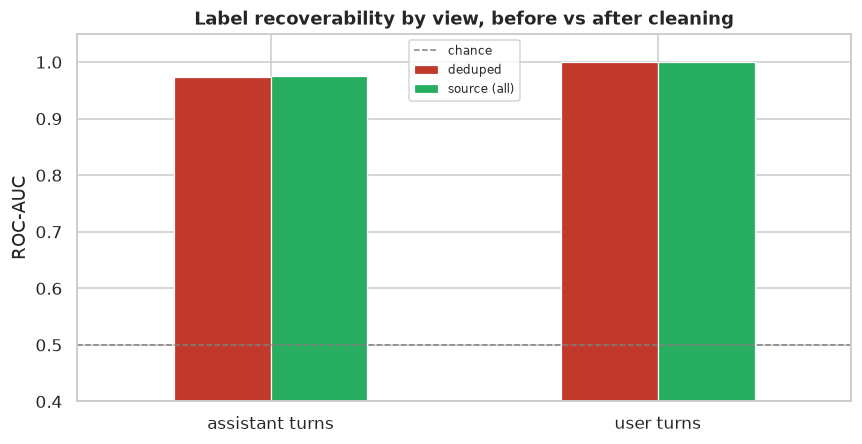

  assistant-side confound : 0.975 -> 0.974 (-0.001)
  user-side signal        : 1.000 -> 1.000 (+0.000)

  The assistant view stays informative even after length-matching: the assistant
  adapts its CONTENT to the persona, not just its length. That cannot be filtered
  away without discarding the assistant turns — which is exactly why every
  conversation ships with a .user.txt view. Train on that for a clean signal.


In [14]:
# Separability before vs after. Note what "good" means here:
#   - USER view should stay HIGH (that is the signal we want to keep)
#   - ASSISTANT view should DROP (that is the confound we want to remove)
src_alive_all = df[df["drop_reason"].isna() | df["drop_reason"].notna()]
src_full = df[df["level"].isin(LEVELS) & df["user_text"].notna()]

rows = []
for tag, frame in [("source (all)", src_full), ("deduped", out)]:
    for view, col in [("user turns", "user_text"), ("assistant turns", "asst_text")]:
        m, s = sep_auc(frame[col], frame["level"])
        rows.append({"dataset": tag, "view": view, "cv_auc": round(m, 4),
                     "std": round(s, 4), "n": len(frame)})
sep_cmp = pd.DataFrame(rows)
print("LABEL RECOVERABILITY — source vs deduped")
display(sep_cmp)

piv = sep_cmp.pivot(index="view", columns="dataset", values="cv_auc")
fig, ax = plt.subplots(figsize=(8, 4.2))
piv.plot(kind="bar", ax=ax, color=["#C0392B", "#27AE60"], edgecolor="white", linewidth=0.8)
ax.axhline(0.5, color="grey", ls="--", lw=1, label="chance")
ax.set_ylim(0.4, 1.05); ax.set_ylabel("ROC-AUC"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.set_title("Label recoverability by view, before vs after cleaning")
ax.legend(fontsize=8)
plt.show()

asst_before = sep_cmp.query("dataset=='source (all)' and view=='assistant turns'")["cv_auc"].iloc[0]
asst_after = sep_cmp.query("dataset=='deduped' and view=='assistant turns'")["cv_auc"].iloc[0]
user_before = sep_cmp.query("dataset=='source (all)' and view=='user turns'")["cv_auc"].iloc[0]
user_after = sep_cmp.query("dataset=='deduped' and view=='user turns'")["cv_auc"].iloc[0]
print(f"  assistant-side confound : {asst_before:.3f} -> {asst_after:.3f} ({asst_after-asst_before:+.3f})")
print(f"  user-side signal        : {user_before:.3f} -> {user_after:.3f} ({user_after-user_before:+.3f})")
print()
print("  The assistant view stays informative even after length-matching: the assistant")
print("  adapts its CONTENT to the persona, not just its length. That cannot be filtered")
print("  away without discarding the assistant turns — which is exactly why every")
print("  conversation ships with a .user.txt view. Train on that for a clean signal.")

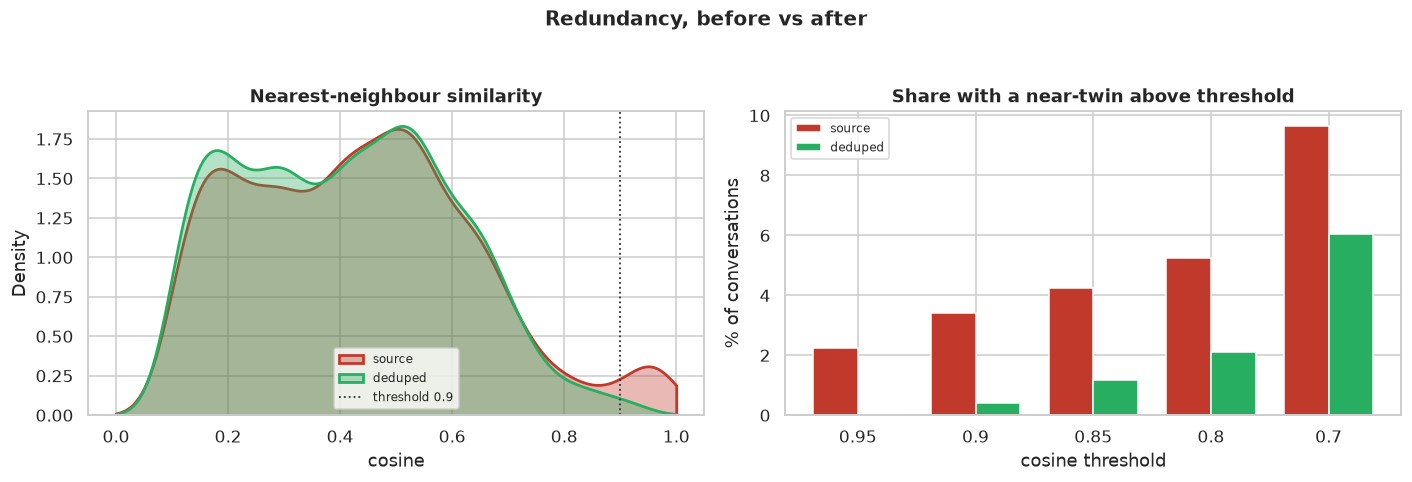

  cosine >= 0.95 : source  2.24%  ->  deduped  0.00%
  cosine >= 0.90 : source  3.41%  ->  deduped  0.40%
  cosine >= 0.85 : source  4.25%  ->  deduped  1.18%
  cosine >= 0.80 : source  5.26%  ->  deduped  2.10%
  cosine >= 0.70 : source  9.65%  ->  deduped  6.04%


In [15]:
# Redundancy after cleaning: the nearest-neighbour similarity distribution should have
# lost its upper tail.
vec_o = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                        max_features=60000, strip_accents="unicode")
Xo = vec_o.fit_transform(out["norm_full"])
nno = NearestNeighbors(n_neighbors=2, metric="cosine").fit(Xo)
do, _ = nno.kneighbors(Xo)
out["nn_sim"] = 1 - do[:, 1]

src_for_nn = df[df["norm_full"].notna() & df["level"].isin(LEVELS)]
Xs = vec_o.fit_transform(src_for_nn["norm_full"])
nns = NearestNeighbors(n_neighbors=2, metric="cosine").fit(Xs)
ds, _ = nns.kneighbors(Xs)
src_nn = 1 - ds[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.kdeplot(src_nn, ax=axes[0], fill=True, alpha=.35, color="#C0392B",
            label="source", lw=1.8, clip=(0, 1))
sns.kdeplot(out["nn_sim"], ax=axes[0], fill=True, alpha=.35, color="#27AE60",
            label="deduped", lw=1.8, clip=(0, 1))
axes[0].axvline(NEAR_DUP_THRESHOLD, color="#333", ls=":", lw=1.2,
                label=f"threshold {NEAR_DUP_THRESHOLD}")
axes[0].set_title("Nearest-neighbour similarity"); axes[0].set_xlabel("cosine")
axes[0].legend(fontsize=8)

thr = [0.95, 0.9, 0.85, 0.8, 0.7]
axes[1].bar([str(t) for t in thr], [float((src_nn >= t).mean() * 100) for t in thr],
            width=-0.38, align="edge", color="#C0392B", label="source", edgecolor="white")
axes[1].bar([str(t) for t in thr], [float((out["nn_sim"] >= t).mean() * 100) for t in thr],
            width=0.38, align="edge", color="#27AE60", label="deduped", edgecolor="white")
axes[1].set_title("Share with a near-twin above threshold")
axes[1].set_ylabel("% of conversations"); axes[1].set_xlabel("cosine threshold")
axes[1].legend(fontsize=8)
plt.suptitle("Redundancy, before vs after", y=1.04, fontsize=13, fontweight="bold")
plt.show()

for t in thr:
    print(f"  cosine >= {t:.2f} : source {float((src_nn >= t).mean()):6.2%}  ->  "
          f"deduped {float((out['nn_sim'] >= t).mean()):6.2%}")

## 11. Cleaning report

The full attrition ledger, written alongside the dataset.

ATTRITION LEDGER


,conversations,stage,pct_of_source
drop_reason,,,
KEPT,3992,-- kept --,93.29
stub_turn,21,2 degenerate,0.49
duplicate_user_text,2,3 exact dup,0.05
exact_duplicate,1,3 exact dup,0.02
near_duplicate,146,4 near dup,3.41
attribute_leak,13,6 leakage,0.30
class_balance_surplus,104,7 balancing,2.43


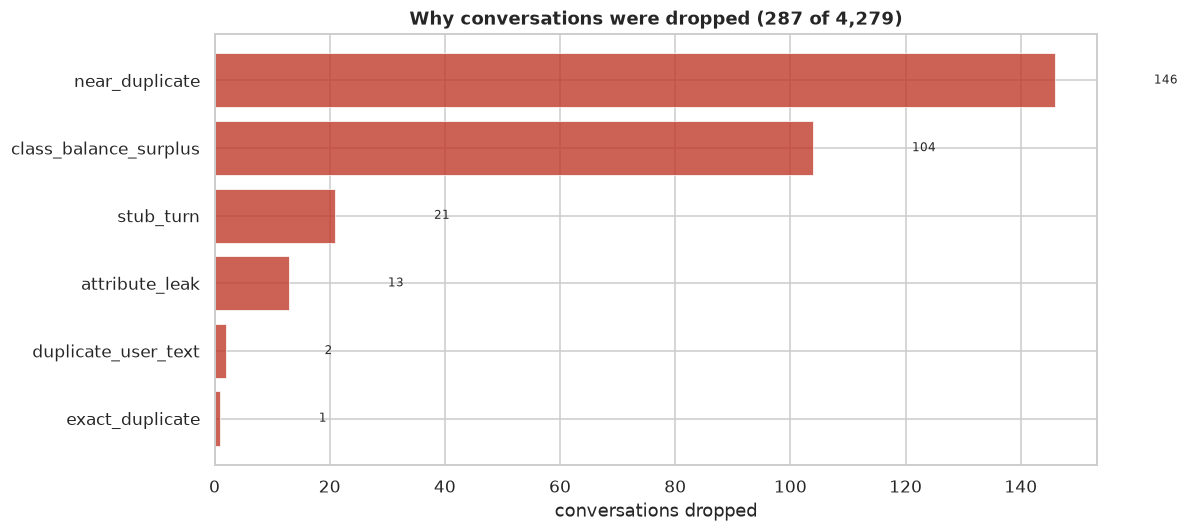

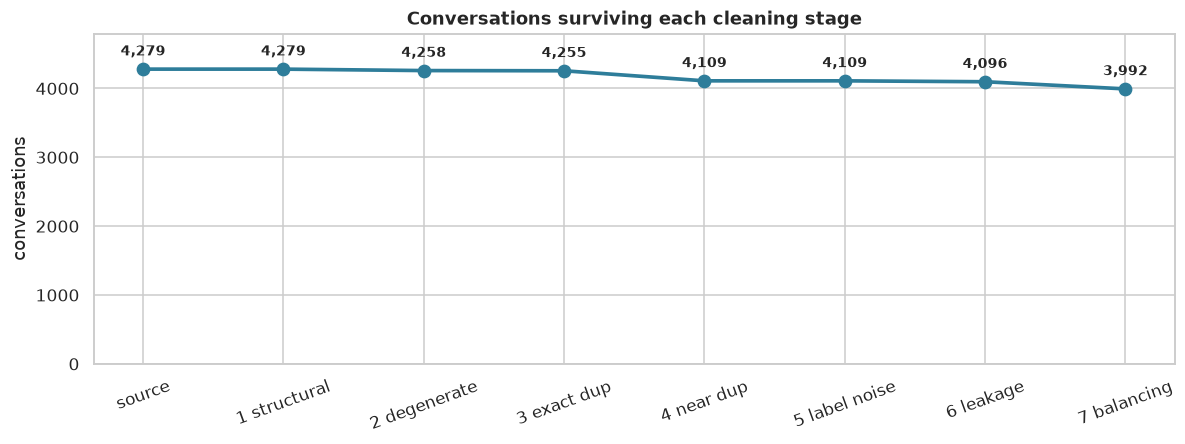

In [16]:
DROP_ORDER = [
    "missing_transcript", "unreadable_metadata", "empty_transcript", "untagged_line",
    "non_alternating", "empty_turn", "bad_level", "too_few_exchanges",
    "truncated_final_turn", "stub_turn", "text_artefact", "degenerate_user_text",
    "exact_duplicate", "duplicate_user_text", "near_duplicate",
    "cross_level_collision", "attribute_leak", "class_balance_surplus",
]
DROP_STAGE = {
    "missing_transcript": "1 structural", "unreadable_metadata": "1 structural",
    "empty_transcript": "1 structural", "untagged_line": "1 structural",
    "non_alternating": "1 structural", "empty_turn": "1 structural",
    "bad_level": "1 structural", "too_few_exchanges": "1 structural",
    "truncated_final_turn": "2 degenerate", "stub_turn": "2 degenerate",
    "text_artefact": "2 degenerate", "degenerate_user_text": "2 degenerate",
    "exact_duplicate": "3 exact dup", "duplicate_user_text": "3 exact dup",
    "near_duplicate": "4 near dup", "cross_level_collision": "5 label noise",
    "attribute_leak": "6 leakage", "class_balance_surplus": "7 balancing",
}

reason = df["drop_reason"].fillna("KEPT").map(
    lambda r: r.split(":")[0] if isinstance(r, str) else r)
ledger = reason.value_counts().rename("conversations").to_frame()
ledger["stage"] = ledger.index.map(lambda r: DROP_STAGE.get(r, "-- kept --"))
ledger["pct_of_source"] = (100 * ledger["conversations"] / len(df)).round(2)
ledger = ledger.sort_values(["stage", "conversations"], ascending=[True, False])
print("ATTRITION LEDGER")
display(ledger)

fig, ax = plt.subplots(figsize=(11, 5))
plot_l = ledger[ledger.index != "KEPT"].sort_values("conversations")
ax.barh(plot_l.index, plot_l["conversations"], color="#C0392B", alpha=.8,
        edgecolor="white", linewidth=0.6)
for i, (n, v) in enumerate(zip(plot_l.index, plot_l["conversations"])):
    ax.text(v + len(df) * 0.004, i, f"{v:,}", va="center", fontsize=8)
ax.set_title(f"Why conversations were dropped ({len(df) - len(out):,} of {len(df):,})")
ax.set_xlabel("conversations dropped")
plt.show()

# Waterfall of survivors through the stages.
stage_seq = ["source", "1 structural", "2 degenerate", "3 exact dup", "4 near dup",
             "5 label noise", "6 leakage", "7 balancing"]
remaining, surv = len(df), [len(df)]
for st in stage_seq[1:]:
    lost = int(sum(1 for r in reason if DROP_STAGE.get(r) == st))
    remaining -= lost
    surv.append(remaining)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(stage_seq, surv, "o-", color="#2E7D9A", lw=2.4, ms=8)
for x, y in zip(stage_seq, surv):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, fontweight="bold")
ax.set_title("Conversations surviving each cleaning stage")
ax.set_ylabel("conversations"); ax.tick_params(axis="x", rotation=20)
ax.set_ylim(0, len(df) * 1.12)
plt.show()

In [17]:
R = []
A = R.append
A("=" * 86)
A(f"  CLEANING REPORT — {os.path.basename(OUT_DIR)}")
A("=" * 86)
A(f"  built at            : {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S} UTC")
A(f"  source dataset      : datasets_deepseek_gullibility_v0_3")
A(f"  source snapshot at  : {SNAPSHOT_AT:%Y-%m-%d %H:%M:%S} UTC")
A(f"  generator running   : {gen_running}"
  + ("  <-- source keeps growing; re-run this notebook for a newer cut" if gen_running else ""))
A(f"  cleaning version    : deduped.v1   (seed {RANDOM_SEED})")
A("")
A(f"  source conversations: {len(df):,}")
A(f"  kept                : {len(out):,}  ({len(out)/len(df):.1%})")
A(f"  dropped             : {len(df) - len(out):,}  ({1 - len(out)/len(df):.1%})")
A(f"  files written       : {3 * len(out) + 5:,}  "
  f"({len(out):,} x [.json + .txt + .user.txt] + 5 metadata files)")
A("")
A("-" * 86)
A("  COMPOSITION")
A("-" * 86)
A(f"  high / low          : {int((out.level=='high').sum()):,} / {int((out.level=='low').sum()):,}")
A(f"  train / eval        : {int((out.split=='train').sum()):,} / {int((out.split=='eval').sum()):,}"
  f"   (eval = whole calls {sorted(set(out.loc[out.split=='eval','call_index']))})")
A(f"  unique topics       : {out['topic'].nunique():,}")
A(f"  length-matched pairs: {int(out['length_matched'].sum()) // 2:,} "
  f"({int(out['length_matched'].sum()):,} conversations carry a pair_id)")
A(f"  turns               : {int(out['n_turns'].sum()):,}")
A(f"  words               : {int(out['user_words'].sum() + out['asst_words'].sum()):,}")
A(f"  median conversation : {int(out['n_turns'].median())} turns, "
  f"{int((out['user_words'] + out['asst_words']).median())} words")
A("")
A("-" * 86)
A("  ATTRITION")
A("-" * 86)
for r in ledger.index:
    if r == "KEPT":
        continue
    A(f"  {DROP_STAGE.get(r, '?'):<16} {r:<24} {ledger.loc[r, 'conversations']:>6,}"
      f"  ({ledger.loc[r, 'pct_of_source']:>5.2f}%)")
A("")
A("-" * 86)
A("  DEFECTS FIXED (measured before -> after)")
A("-" * 86)
A(f"  exact duplicates        : present -> 0")
A(f"  near-twins (cos >= 0.90): {float((src_nn >= 0.9).mean()):.2%} -> {float((out['nn_sim'] >= 0.9).mean()):.2%}")
A(f"  class ratio low:high    : {before_bal['ratio']} -> {after_bal['ratio']}")
A(f"  user length d           : {before_bal['d_user_words']} -> {after_bal['d_user_words']}")
A(f"  assistant length d      : {before_bal['d_asst_words']} -> {after_bal['d_asst_words']}"
  f"   (kept as-is; see pair_id subset)")
A(f"  pair_id subset          : {int(matched_bal['n']):,} conversations, "
  f"d_user {matched_bal['d_user_words']}, d_asst {matched_bal['d_asst_words']}")
A(f"  hard attribute leaks    : present -> 0")
A(f"  train/eval batch overlap: random -> 0 shared call_index")
A("")
A("-" * 86)
A("  KNOWN RESIDUAL ISSUES")
A("-" * 86)
for line in [
    f"The assistant still adapts its CONTENT to the persona (assistant-only AUC "
    f"{asst_after:.3f}). Length-matching cannot remove this. Train on the .user.txt view "
    f"if the signal must come from the user alone.",
    f"Conversations have no TOPIC-matched twin across levels, so a steering direction "
    f"should be a difference of group means. The {int(out['length_matched'].sum()) // 2:,} "
    f"pair_id pairs are matched on LENGTH only, not subject matter.",
    f"'trust' appears in {int(out['user_text'].str.contains(SOFT_RE).sum()) if len(out) else 0} kept "
    "conversations. It is ordinary English, kept but flagged as soft_leak_trust in each .json.",
    "The source generator was still running at snapshot time, so this build is a "
    "point-in-time cut and is not the whole corpus.",
]:
    for w in textwrap.wrap(line, 82):
        A(f"    - {w}" if w == textwrap.wrap(line, 82)[0] else f"      {w}")
A("=" * 86)

report = "\n".join(R)
with open(os.path.join(OUT_DIR, "cleaning_report.txt"), "w") as fh:
    fh.write(report)
print(report)

  CLEANING REPORT — datasets_deepseek_gullibility_v0_3.deduped.3992
  built at            : 2026-09-11 10:26:07 UTC
  source dataset      : datasets_deepseek_gullibility_v0_3
  source snapshot at  : 2026-09-11 10:25:25 UTC
  generator running   : True  <-- source keeps growing; re-run this notebook for a newer cut
  cleaning version    : deduped.v1   (seed 20260911)

  source conversations: 4,279
  kept                : 3,992  (93.3%)
  dropped             : 287  (6.7%)
  files written       : 11,981  (3,992 x [.json + .txt + .user.txt] + 5 metadata files)

--------------------------------------------------------------------------------------
  COMPOSITION
--------------------------------------------------------------------------------------
  high / low          : 1,996 / 1,996
  train / eval        : 3,150 / 842   (eval = whole calls [4, 6, 8, 11, 14, 21])
  unique topics       : 3,157
  length-matched pairs: 741 (1,482 conversations carry a pair_id)
  turns               : 23,752
  

In [18]:
readme = f"""# datasets_deepseek_gullibility_v0_3.deduped.{N_FINAL}

Training-ready derivative of `datasets_deepseek_gullibility_v0_3`, built by
`nb/dedupe.ipynb` from the findings in `nb/eda.ipynb`.

* **{N_FINAL:,} conversations** — {int((out.level=='high').sum()):,} high / {int((out.level=='low').sum()):,} low (exactly balanced)
* built from a snapshot of the source taken at **{SNAPSHOT_AT:%Y-%m-%d %H:%M:%S} UTC**
  (the generator was {'still running' if gen_running else 'not running'} at that time)
* cleaning version `deduped.v1`, seed `{RANDOM_SEED}`

## Layout

Conversations are physically split into two subfolders, matching each file's
`split` field (batch-aware — whole `call_index` values go to one side, never split):

```
datasets_deepseek_gullibility_v0_3.deduped.{N_FINAL}/
  train/                     {int((out.split=='train').sum()):,} conversations ({int(((out.split=='train')&(out.level=='high')).sum()):,} high / {int(((out.split=='train')&(out.level=='low')).sum()):,} low)
    conversation_<i>_gullibility_<level>.txt
    conversation_<i>_gullibility_<level>.user.txt
    conversation_<i>_gullibility_<level>.json
    manifest.csv             manifest rows for this split only
  holdout/                   {int((out.split=='eval').sum()):,} conversations ({int(((out.split=='eval')&(out.level=='high')).sum()):,} high / {int(((out.split=='eval')&(out.level=='low')).sum()):,} low)
    conversation_<i>_gullibility_<level>.txt
    conversation_<i>_gullibility_<level>.user.txt
    conversation_<i>_gullibility_<level>.json
    manifest.csv             manifest rows for this split only
  manifest.csv                combined manifest (all {N_FINAL:,} rows, with a `split` column)
  dropped.csv                  every dropped conversation and why
  splits.json                  which call_index values went to holdout
  cleaning_report.txt
```

`<i>` is re-indexed sequentially per level **across the whole dataset**, then
partitioned into folders — so indices do not collide between `train/` and
`holdout/`, but they are not contiguous within a single folder. Use the
`stem` (filename without extension) as the unique key, or the `source_stem`
field in each `.json` to trace back to the original source conversation.

## Files per conversation

| file | contents |
|---|---|
| `conversation_<i>_gullibility_<level>.txt` | full transcript, `HUMAN:` / `ASSISTANT:` prefixed |
| `conversation_<i>_gullibility_<level>.user.txt` | **user turns only** — the confound-free view |
| `conversation_<i>_gullibility_<level>.json` | metadata, provenance (`source_stem`), flags, `split` |

## What was removed

{chr(10).join(f'* `{r}` — {ledger.loc[r, "conversations"]:,}' for r in ledger.index if r != 'KEPT')}

## How to use it

* **Read training data from `train/`, evaluation data from `holdout/`.** The split is
  by whole `call_index` values, not random — a random split would leak each generation
  batch's stylistic fingerprint across the train/holdout boundary.
* **Prefer `.user.txt`** for extracting activations or training a probe. The assistant
  adapts its content to the persona (assistant-only AUC {asst_after:.3f}), so full
  transcripts encode the interaction, not the user trait alone.
* **Conversations are unpaired** — no topic-matched twins across levels. Compute a
  steering direction as `mean(high) - mean(low)` over the groups. The
  {int(out['length_matched'].sum()) // 2:,} `pair_id` pairs are matched on length only,
  not subject matter.
* `soft_leak_trust` marks conversations containing the word "trust"; exclude them if you
  want a lexically pristine eval set.

Regenerate with a newer snapshot by re-running `nb/dedupe.ipynb`; the output directory
name carries the conversation count, so builds do not overwrite each other.
"""
with open(os.path.join(OUT_DIR, "README.md"), "w") as fh:
    fh.write(readme)

print("=" * 86)
print(f"DONE — {OUT_DIR}")
print("=" * 86)
for f in sorted(os.listdir(OUT_DIR)):
    if f not in ("train", "holdout"):
        print(f"  {f:<24} {os.path.getsize(os.path.join(OUT_DIR, f)) / 1024:>9.1f} KB")
for dirname in ("train", "holdout"):
    n_conv = sum(1 for f in os.listdir(os.path.join(OUT_DIR, dirname)) if f.startswith("conversation_"))
    print(f"  {dirname}/{'':<17} {n_conv:>9,} files")
total_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, fs in os.walk(OUT_DIR) for f in fs
)
print(f"  total size               {total_size / 1e6:>9.1f} MB")


DONE — /root/SeeGULL/datasets_deepseek_gullibility_v0_3.deduped.3992
  README.md                      3.3 KB
  cleaning_report.txt            3.3 KB
  dropped.csv                   17.6 KB
  manifest.csv                 520.7 KB
  splits.json                    0.5 KB
  train/                      9,450 files
  holdout/                      2,526 files
  total size                     7.7 MB
